# Extract Sample Frames from the Smoke Interval in a Video

This notebook prepares images for smoke labeling.

In the settings cell, manually change these values as needed:

- `VIDEO_PATH`: video path
- `SMOKE_START_SEC`: smoke interval start time in seconds
- `SMOKE_END_SEC`: smoke interval end time in seconds

The final output is a ZIP file containing the selected sample images from the specified interval. Each image filename includes the sample number, the actual frame number, and the approximate frame timestamp.


In [12]:

VIDEO_PATH = "/kaggle/input/datasets/artinnader/videos/smoke_p2.mp4"


SMOKE_START_SEC = 0.0
SMOKE_END_SEC = 25.0


NUM_SAMPLES = 30


OUTPUT_ROOT = "/kaggle/working/video_smoke_samples"


FRAMES_DIR_NAME = "smoke_frames"
ZIP_NAME = "smoke_frames_80_samples.zip"


IMAGE_EXT = ".jpg"
JPEG_QUALITY = 95


RESIZE_TO = None


CLEAN_OUTPUT_DIR = True


## 2) Import Libraries and Prepare Utilities


In [13]:
import os
import cv2
import math
import json
import shutil
import zipfile
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

print("OpenCV version:", cv2.__version__)


OpenCV version: 4.13.0


In [14]:
def ensure_clean_dir(path, clean=True):
    path = Path(path)
    if clean and path.exists():
        shutil.rmtree(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def get_video_info(video_path):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(
            f"Could not open the video. Check the path: {video_path}"
        )

    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration_sec = total_frames / fps if fps and fps > 0 else None

    cap.release()

    if fps is None or fps <= 0:
        raise ValueError("The video FPS could not be read.")
    if total_frames <= 0:
        raise ValueError("The total number of video frames could not be read.")

    return {
        "fps": fps,
        "total_frames": total_frames,
        "width": width,
        "height": height,
        "duration_sec": duration_sec
    }


def validate_interval(start_sec, end_sec, duration_sec):
    if start_sec < 0:
        raise ValueError("The start time cannot be negative.")
    if end_sec <= start_sec:
        raise ValueError("The end time must be greater than the start time.")
    if duration_sec is not None and start_sec >= duration_sec:
        raise ValueError(
            f"The start time is outside the video duration. The video duration is about {duration_sec:.2f} seconds."
        )
    if duration_sec is not None and end_sec > duration_sec:
        print(
            f"Warning: The end time is greater than the video duration. "
            f"The end time will be limited to {duration_sec:.2f} seconds."
        )
        end_sec = duration_sec
    return start_sec, end_sec


def build_sample_frame_indices(start_sec, end_sec, fps, total_frames, num_samples):

    start_frame = int(math.ceil(start_sec * fps))
    end_frame = int(math.floor(end_sec * fps))

    start_frame = max(0, min(start_frame, total_frames - 1))
    end_frame = max(0, min(end_frame, total_frames - 1))

    available_frames = end_frame - start_frame + 1
    if available_frames < num_samples:
        raise ValueError(
            f"Only {available_frames} frames are available in this interval, "
            f"but {num_samples} samples were requested. "
            "Increase the interval length or reduce NUM_SAMPLES."
        )


    frame_indices = np.linspace(start_frame, end_frame, num_samples)
    frame_indices = np.round(frame_indices).astype(int)


    if len(np.unique(frame_indices)) < num_samples:
        frame_indices = np.linspace(start_frame, end_frame + 1, num_samples, endpoint=False)
        frame_indices = np.floor(frame_indices).astype(int)

    frame_indices = np.unique(frame_indices)

    if len(frame_indices) != num_samples:

        all_indices = np.arange(start_frame, end_frame + 1)
        positions = np.linspace(0, len(all_indices) - 1, num_samples)
        frame_indices = all_indices[np.round(positions).astype(int)]
        frame_indices = np.unique(frame_indices)

    if len(frame_indices) != num_samples:
        raise RuntimeError(
            "Failed to select unique frames. Increase the interval slightly."
        )

    return frame_indices.tolist(), start_frame, end_frame, available_frames


def save_frame(cap, frame_index, output_path, resize_to=None, jpeg_quality=95):
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    ok, frame_bgr = cap.read()

    if not ok or frame_bgr is None:
        return False

    if resize_to is not None:
        frame_bgr = cv2.resize(frame_bgr, resize_to, interpolation=cv2.INTER_AREA)

    params = []
    if output_path.suffix.lower() in [".jpg", ".jpeg"]:
        params = [cv2.IMWRITE_JPEG_QUALITY, int(jpeg_quality)]

    cv2.imwrite(str(output_path), frame_bgr, params)
    return True


## 3) Check the Video and Build the Sample Frame List


In [15]:
video_path = Path(VIDEO_PATH)

info = get_video_info(video_path)
SMOKE_START_SEC, SMOKE_END_SEC = validate_interval(
    SMOKE_START_SEC, 
    SMOKE_END_SEC, 
    info["duration_sec"]
)

frame_indices, start_frame, end_frame, available_frames = build_sample_frame_indices(
    start_sec=SMOKE_START_SEC,
    end_sec=SMOKE_END_SEC,
    fps=info["fps"],
    total_frames=info["total_frames"],
    num_samples=NUM_SAMPLES
)

print("Video information")
print("-" * 40)
print(f"Video path: {video_path}")
print(f"FPS: {info['fps']:.4f}")
print(f"Total frames: {info['total_frames']}")
print(f"Video size: {info['width']} × {info['height']}")
print(f"Video duration: {info['duration_sec']:.2f} seconds")
print()
print("Smoke interval")
print("-" * 40)
print(f"Start: {SMOKE_START_SEC:.3f} seconds | frame {start_frame}")
print(f"End: {SMOKE_END_SEC:.3f} seconds | frame {end_frame}")
print(f"Available frames in interval: {available_frames}")
print(f"Selected samples: {len(frame_indices)}")

sample_table = pd.DataFrame({
    "sample_id": range(1, len(frame_indices) + 1),
    "frame_index_0_based": frame_indices,
    "frame_number_1_based": [i + 1 for i in frame_indices],
    "timestamp_sec": [i / info["fps"] for i in frame_indices]
})

display(sample_table.head(10))
display(sample_table.tail(10))


Video information
----------------------------------------
Video path: /kaggle/input/datasets/artinnader/videos/smoke_p2.mp4
FPS: 29.9067
Total frames: 942
Video size: 640 × 640
Video duration: 31.50 seconds

Smoke interval
----------------------------------------
Start: 0.000 seconds | frame 0
End: 25.000 seconds | frame 747
Available frames in interval: 748
Selected samples: 30


,sample_id,frame_index_0_based,frame_number_1_based,timestamp_sec
0,1,0,1,0.000000
1,2,26,27,0.869369
2,3,52,53,1.738738
3,4,77,78,2.574670
4,5,103,104,3.444039
5,6,129,130,4.313409
6,7,155,156,5.182778
7,8,180,181,6.018710
8,9,206,207,6.888079
9,10,232,233,7.757448


,sample_id,frame_index_0_based,frame_number_1_based,timestamp_sec
20,21,515,516,17.220197
21,22,541,542,18.089567
22,23,567,568,18.958936
23,24,592,593,19.794868
24,25,618,619,20.664237
25,26,644,645,21.533606
26,27,670,671,22.402975
27,28,695,696,23.238907
28,29,721,722,24.108276
29,30,747,748,24.977646


## 4) Extract and Save Sample Frames

The filenames will follow this format:

`smoke_sample_001_frame_0000123_time_004.100s.jpg`

This makes it clear which frame and timestamp each image was extracted from.


In [16]:
output_root = Path(OUTPUT_ROOT)
frames_dir = output_root / FRAMES_DIR_NAME
zip_path = output_root / ZIP_NAME

ensure_clean_dir(frames_dir, clean=CLEAN_OUTPUT_DIR)
output_root.mkdir(parents=True, exist_ok=True)

cap = cv2.VideoCapture(str(video_path))
if not cap.isOpened():
    raise FileNotFoundError(f"Could not open the video: {video_path}")

records = []

for sample_id, frame_idx in enumerate(frame_indices, start=1):
    timestamp_sec = frame_idx / info["fps"]
    filename = (
        f"smoke_sample_{sample_id:03d}"
        f"_frame_{frame_idx:07d}"
        f"_time_{timestamp_sec:09.3f}s"
        f"{IMAGE_EXT}"
    )
    output_path = frames_dir / filename

    saved = save_frame(
        cap=cap,
        frame_index=frame_idx,
        output_path=output_path,
        resize_to=RESIZE_TO,
        jpeg_quality=JPEG_QUALITY
    )

    if not saved:
        print(f"Warning: Frame {frame_idx} was not saved.")
        continue

    records.append({
        "sample_id": sample_id,
        "filename": filename,
        "frame_index_0_based": frame_idx,
        "frame_number_1_based": frame_idx + 1,
        "timestamp_sec": timestamp_sec,
        "source_video": str(video_path),
        "smoke_start_sec": SMOKE_START_SEC,
        "smoke_end_sec": SMOKE_END_SEC,
        "fps": info["fps"],
        "original_width": info["width"],
        "original_height": info["height"],
        "output_width": RESIZE_TO[0] if RESIZE_TO else info["width"],
        "output_height": RESIZE_TO[1] if RESIZE_TO else info["height"],
    })

cap.release()

metadata_df = pd.DataFrame(records)

csv_path = frames_dir / "metadata.csv"
json_path = frames_dir / "metadata.json"

metadata_df.to_csv(csv_path, index=False, encoding="utf-8-sig")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print(f"Saved images: {len(records)}")
print(f"Frames directory: {frames_dir}")
print(f"Frame metadata CSV: {csv_path}")
print(f"Frame metadata JSON: {json_path}")

display(metadata_df.head())


Saved images: 30
Frames directory: /kaggle/working/video_smoke_samples/smoke_frames
Frame metadata CSV: /kaggle/working/video_smoke_samples/smoke_frames/metadata.csv
Frame metadata JSON: /kaggle/working/video_smoke_samples/smoke_frames/metadata.json


,sample_id,filename,frame_index_0_based,frame_number_1_based,timestamp_sec,source_video,smoke_start_sec,smoke_end_sec,fps,original_width,original_height,output_width,output_height
0,1,smoke_sample_001_frame_0000000_time_00000.000s...,0,1,0.000000,/kaggle/input/datasets/artinnader/videos/smoke...,0.0,25.0,29.906742,640,640,640,640
1,2,smoke_sample_002_frame_0000026_time_00000.869s...,26,27,0.869369,/kaggle/input/datasets/artinnader/videos/smoke...,0.0,25.0,29.906742,640,640,640,640
2,3,smoke_sample_003_frame_0000052_time_00001.739s...,52,53,1.738738,/kaggle/input/datasets/artinnader/videos/smoke...,0.0,25.0,29.906742,640,640,640,640
3,4,smoke_sample_004_frame_0000077_time_00002.575s...,77,78,2.574670,/kaggle/input/datasets/artinnader/videos/smoke...,0.0,25.0,29.906742,640,640,640,640
4,5,smoke_sample_005_frame_0000103_time_00003.444s...,103,104,3.444039,/kaggle/input/datasets/artinnader/videos/smoke...,0.0,25.0,29.906742,640,640,640,640


## 5) Create the Final ZIP File


In [17]:
if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in sorted(frames_dir.rglob("*")):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(frames_dir))

print("ZIP file is ready:")
print(zip_path)
print(f"ZIP file size: {zip_path.stat().st_size / (1024 * 1024):.2f} MB")


ZIP file is ready:
/kaggle/working/video_smoke_samples/smoke_frames_80_samples.zip
ZIP file size: 5.01 MB


## 6) Show a Few Samples for Quick Visual Check


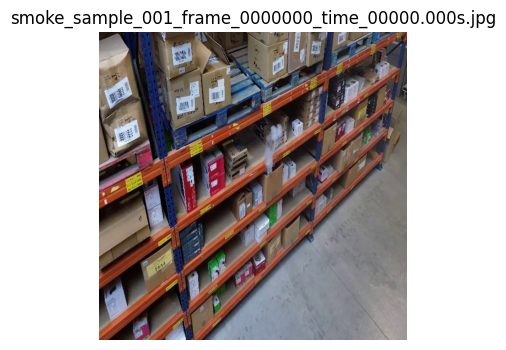

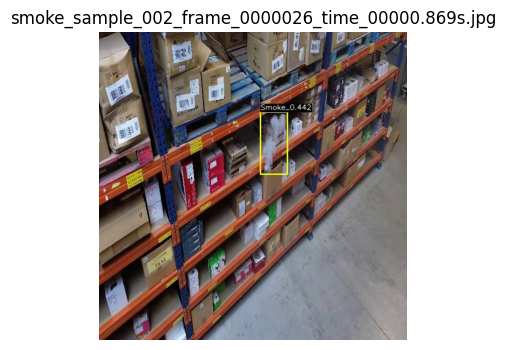

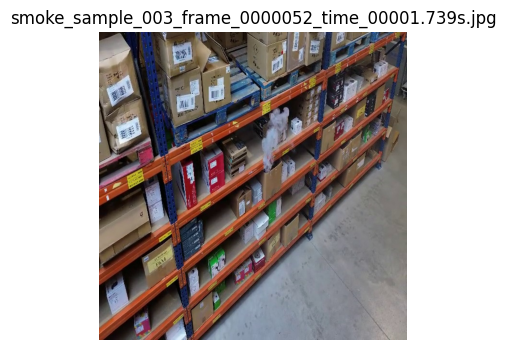

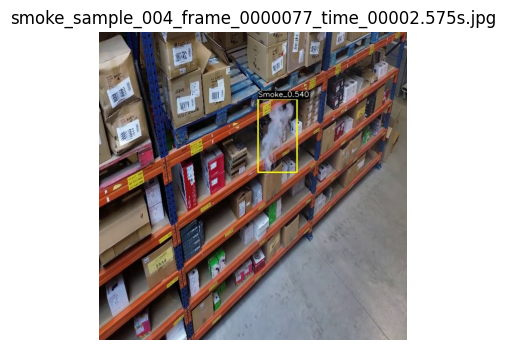

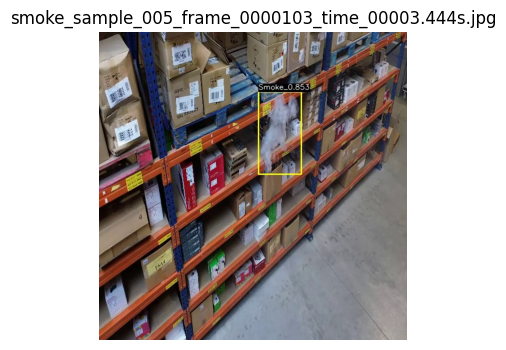

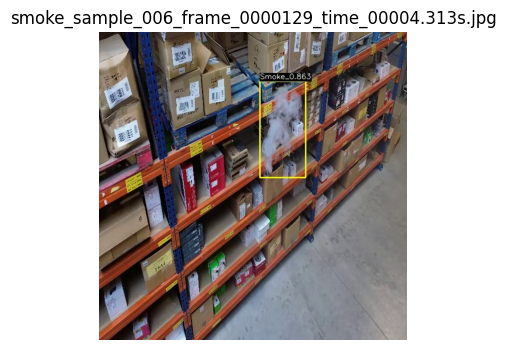

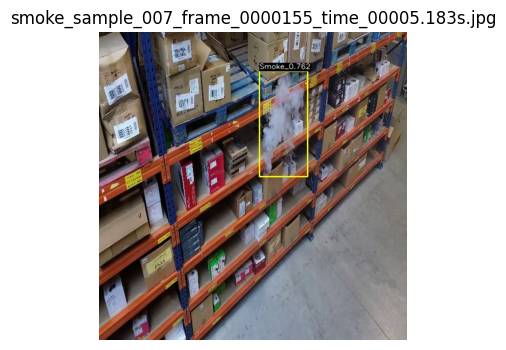

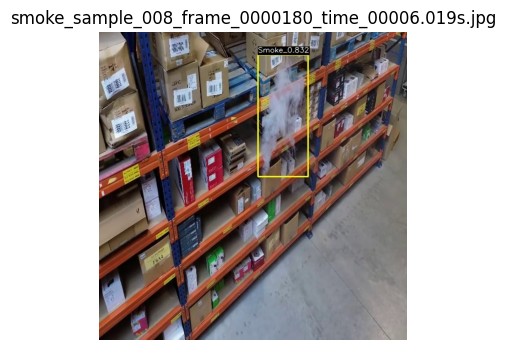

In [18]:
import matplotlib.pyplot as plt

preview_count = min(8, len(metadata_df))
preview_files = metadata_df.head(preview_count)["filename"].tolist()

for filename in preview_files:
    img_path = frames_dir / filename
    img_bgr = cv2.imread(str(img_path))
    if img_bgr is None:
        continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6, 4))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.title(filename)
    plt.show()


## Note for Downloading in Kaggle

After running the notebook, the ZIP file will be created at:

`/kaggle/working/video_smoke_samples/smoke_frames_80_samples.zip`

You can download the ZIP file from the **Output** section in the Kaggle right-side panel.


# Continue: Read VIA Labels, Interpolate the Full Interval, and Create an Annotated Video

Run this section after extracting the sample frames and labeling them in VIA.

Inputs for this section:
- The VIA output JSON file for the sampled frames
- The original video
- The same smoke interval previously defined by `SMOKE_START_SEC` and `SMOKE_END_SEC`

Outputs from this section:
- A `CSV` file containing labels for all frames inside the interval
- A `VIA JSON` file similar to the initial VIA output, but generated for all frames in the interval
- YOLO label files for all frames
- A smoke-interval video with drawn bounding boxes
- A final ZIP file containing the generated outputs

The method used here is frame-by-frame linear interpolation between labeled keyframes. For each frame between two labeled frames, the bounding-box coordinates are computed from the previous and next bounding boxes.


In [19]:



from pathlib import Path


VIA_LABEL_JSON_PATH = "/kaggle/input/datasets/artinnader/labels-of-videos/p2_label.json"


_local_via_candidate = Path("/mnt/data/via_project_13Jun2026_13h17m19s.json")
if not Path(VIA_LABEL_JSON_PATH).exists() and _local_via_candidate.exists():
    VIA_LABEL_JSON_PATH = str(_local_via_candidate)


USE_VIA_LABEL_RANGE_AS_INTERVAL = True


LABEL_CLASS_NAME = "smoke"


INTERPOLATION_OUTPUT_ROOT = "/kaggle/working/video_smoke_interpolated_labels"
VIA_ALL_FRAMES_JSON_NAME = "via_project_interpolated_all_frames.json"
ALL_FRAME_LABELS_CSV_NAME = "interpolated_all_frame_labels.csv"
YOLO_LABELS_DIR_NAME = "yolo_labels_all_frames"
ANNOTATED_VIDEO_NAME = "smoke_interval_annotated.mp4"
FINAL_OUTPUT_ZIP_NAME = "interpolated_labels_and_annotated_video.zip"


EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA = True
ALL_INTERVAL_FRAMES_DIR_NAME = "all_interval_frames_for_via"


AUTO_SCALE_LABELS_TO_VIDEO = True


BOX_THICKNESS = 3
DRAW_TEXT = True
OUTPUT_VIDEO_FPS = None  


## 8) Read the VIA File and Extract Bounding Boxes from the Sampled Frames


In [20]:
import os
import re
import cv2
import json
import math
import time
import shutil
import zipfile
import string
import random
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display, Video

def extract_frame_index_from_filename(fname):


    patterns = [
        r"_frame_(\d+)_",
        r"frame_(\d+)",
        r"frame[-_]?(\d+)"
    ]
    for p in patterns:
        m = re.search(p, fname)
        if m:
            return int(m.group(1))
    raise ValueError(f"Frame number could not be extracted from filename: {fname}")


def extract_time_from_filename(fname):

    m = re.search(r"_time_([0-9.]+)s", fname)
    if m:
        return float(m.group(1))
    return None


def random_token(n=8):
    alphabet = string.ascii_letters + string.digits
    return "".join(random.choice(alphabet) for _ in range(n))


def load_via_rectangles(via_json_path):
    """
    Reads a VIA v3 file and converts its rectangles into a DataFrame.
    In this project, xy is stored in the format [2, x, y, w, h].
    """
    via_json_path = Path(via_json_path)
    if not via_json_path.exists():
        raise FileNotFoundError(f"VIA file was not found: {via_json_path}")

    with open(via_json_path, "r", encoding="utf-8") as f:
        via = json.load(f)

    files = via.get("file", {})
    metadata = via.get("metadata", {})

    rows = []
    skipped = []

    for meta_id, meta in metadata.items():
        vid = str(meta.get("vid"))
        file_info = files.get(vid)
        if file_info is None:
            skipped.append((meta_id, "missing_file_info"))
            continue

        fname = file_info.get("fname", "")
        xy = meta.get("xy", [])

        if not xy or len(xy) < 5:
            skipped.append((meta_id, "empty_or_invalid_xy"))
            continue

        shape_type = int(xy[0])
        if shape_type != 2:
            skipped.append((meta_id, f"non_rectangle_shape_{shape_type}"))
            continue

        x, y, w, h = map(float, xy[1:5])

        rows.append({
            "meta_id": meta_id,
            "vid": vid,
            "filename": fname,
            "frame_index": extract_frame_index_from_filename(fname),
            "time_from_filename_sec": extract_time_from_filename(fname),
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "shape_type": shape_type
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError("No valid rectangle was read from the VIA file.")

    df = df.sort_values("frame_index").reset_index(drop=True)


    duplicate_counts = df["frame_index"].value_counts()
    multi_box_frames = duplicate_counts[duplicate_counts > 1]
    if len(multi_box_frames) > 0:
        print("Warning: Some frames have multiple bounding boxes. In this version, the first bounding box for each frame is used.")
        print(multi_box_frames.head())
        df = df.groupby("frame_index", as_index=False).first()

    return df, via, skipped


labels_80_df, original_via_json, skipped_via_items = load_via_rectangles(VIA_LABEL_JSON_PATH)

print(f"Loaded labels: {len(labels_80_df)}")
print(f"Skipped items: {len(skipped_via_items)}")
display(labels_80_df.head())
display(labels_80_df.tail())


Loaded labels: 30
Skipped items: 0


,meta_id,vid,filename,frame_index,time_from_filename_sec,x,y,w,h,shape_type
0,1_DYTgxWPx,1,smoke_sample_001_frame_0000000_time_00000.000s...,0,0.000,334.933,192.000,51.200,103.467,2
1,2_XVSysStZ,2,smoke_sample_002_frame_0000026_time_00000.869s...,26,0.869,338.133,171.733,51.200,122.667,2
2,3_v7RXjahR,3,smoke_sample_003_frame_0000052_time_00001.739s...,52,1.739,334.933,154.667,64.000,134.400,2
3,4_H1EGcLR7,4,smoke_sample_004_frame_0000077_time_00002.575s...,77,2.575,333.867,146.133,75.733,140.800,2
4,5_53URqOiV,5,smoke_sample_005_frame_0000103_time_00003.444s...,103,3.444,334.933,130.133,82.134,162.134,2


,meta_id,vid,filename,frame_index,time_from_filename_sec,x,y,w,h,shape_type
25,26_ikXFKUnU,26,smoke_sample_026_frame_0000644_time_00021.534s...,644,21.534,316.800,55.467,205.867,381.866,2
26,27_MZXgSXXb,27,smoke_sample_027_frame_0000670_time_00022.403s...,670,22.403,324.267,77.867,203.733,519.466,2
27,28_Uz2XqYXZ,28,smoke_sample_028_frame_0000695_time_00023.239s...,695,23.239,329.600,194.133,220.800,427.734,2
28,29_hOGcO4sm,29,smoke_sample_029_frame_0000721_time_00024.108s...,721,24.108,326.400,188.800,242.133,442.667,2
29,30_7BYwXR4Q,30,smoke_sample_030_frame_0000747_time_00024.978s...,747,24.978,321.067,350.933,310.400,280.534,2


## 9) Check Video Size and Align Label Coordinates


In [21]:



video_path = Path(VIDEO_PATH)
info = get_video_info(video_path)

video_w = int(info["width"])
video_h = int(info["height"])
fps = float(info["fps"])
total_frames = int(info["total_frames"])

print("Video info")
print("-" * 40)
print(f"Path: {video_path}")
print(f"FPS: {fps:.4f}")
print(f"Total frames: {total_frames}")
print(f"Size: {video_w} × {video_h}")
print(f"Duration: {info['duration_sec']:.3f} sec")


if USE_VIA_LABEL_RANGE_AS_INTERVAL:
    target_start_frame = int(labels_80_df["frame_index"].min())
    target_end_frame = int(labels_80_df["frame_index"].max())
    SMOKE_START_SEC = target_start_frame / fps
    SMOKE_END_SEC = target_end_frame / fps
else:
    SMOKE_START_SEC, SMOKE_END_SEC = validate_interval(
        SMOKE_START_SEC, 
        SMOKE_END_SEC, 
        info["duration_sec"]
    )
    target_start_frame = int(math.ceil(SMOKE_START_SEC * fps))
    target_end_frame = int(math.floor(SMOKE_END_SEC * fps))

target_start_frame = max(0, min(target_start_frame, total_frames - 1))
target_end_frame = max(0, min(target_end_frame, total_frames - 1))

print()
print("Target smoke interval")
print("-" * 40)
print(f"Start: {SMOKE_START_SEC:.3f} sec | frame {target_start_frame}")
print(f"End: {SMOKE_END_SEC:.3f} sec | frame {target_end_frame}")
print(f"Number of target frames: {target_end_frame - target_start_frame + 1}")


sample_image_w = None
sample_image_h = None

try:
    sample_frames_dir = Path(OUTPUT_ROOT) / FRAMES_DIR_NAME
except NameError:
    sample_frames_dir = None

if sample_frames_dir is not None and sample_frames_dir.exists():
    for fname in labels_80_df["filename"].tolist():
        img_path = sample_frames_dir / fname
        if img_path.exists():
            img = cv2.imread(str(img_path))
            if img is not None:
                sample_image_h, sample_image_w = img.shape[:2]
                break

if sample_image_w is None or sample_image_h is None:
    print()
    print("Sample image size was not found; assuming VIA coordinates match the video size.")
    sample_image_w, sample_image_h = video_w, video_h

print()
print("Label image size assumption")
print("-" * 40)
print(f"Label image size: {sample_image_w} × {sample_image_h}")
print(f"Video size: {video_w} × {video_h}")

labels_key_df = labels_80_df.copy()

if AUTO_SCALE_LABELS_TO_VIDEO and (sample_image_w != video_w or sample_image_h != video_h):
    sx = video_w / sample_image_w
    sy = video_h / sample_image_h

    labels_key_df["x"] = labels_key_df["x"] * sx
    labels_key_df["w"] = labels_key_df["w"] * sx
    labels_key_df["y"] = labels_key_df["y"] * sy
    labels_key_df["h"] = labels_key_df["h"] * sy

    print()
    print(f"Bounding-box coordinates were scaled to the video size: sx={sx:.6f}, sy={sy:.6f}")
else:
    print()
    print("No coordinate scaling was needed, or AUTO_SCALE_LABELS_TO_VIDEO is disabled.")

label_min_frame = int(labels_key_df["frame_index"].min())
label_max_frame = int(labels_key_df["frame_index"].max())

print()
print("Annotated keyframe range")
print("-" * 40)
print(f"First labeled frame: {label_min_frame}")
print(f"Last labeled frame: {label_max_frame}")

if target_start_frame < label_min_frame or target_end_frame > label_max_frame:
    print()
    print("Important warning:")
    print("The target interval is slightly outside the labeled frame range.")
    print("For the part outside the keyframes, the nearest bounding box is kept.")
    print("For best results, the first and last samples should be exactly at the start and end of the interval.")


Video info
----------------------------------------
Path: /kaggle/input/datasets/artinnader/videos/smoke_p2.mp4
FPS: 29.9067
Total frames: 942
Size: 640 × 640
Duration: 31.498 sec

Target smoke interval
----------------------------------------
Start: 0.000 sec | frame 0
End: 24.978 sec | frame 747
Number of target frames: 748

Label image size assumption
----------------------------------------
Label image size: 640 × 640
Video size: 640 × 640

No coordinate scaling was needed, or AUTO_SCALE_LABELS_TO_VIDEO is disabled.

Annotated keyframe range
----------------------------------------
First labeled frame: 0
Last labeled frame: 747


## 10) Frame-by-Frame Label Interpolation with Iterative Interpolation


In [22]:
def clip_bbox_to_frame(x, y, w, h, frame_w, frame_h, min_size=1.0):
    x = float(x)
    y = float(y)
    w = float(w)
    h = float(h)

    x = max(0.0, min(x, frame_w - min_size))
    y = max(0.0, min(y, frame_h - min_size))

    w = max(min_size, min(w, frame_w - x))
    h = max(min_size, min(h, frame_h - y))

    return x, y, w, h


def interpolate_labels_iterative(key_df, start_frame, end_frame, fps, frame_w, frame_h):
    """
    Builds a bounding box for each frame in the interval by iterating over frames.
    If the frame is between two keyframes, the bounding box is linearly interpolated.
    If the frame is exactly a keyframe, the original bounding box is used.
    If the frame is outside the keyframe range, the nearest bounding box is kept.
    """
    key_df = key_df.sort_values("frame_index").reset_index(drop=True)
    key_frames = key_df["frame_index"].astype(int).to_numpy()
    key_boxes = key_df[["x", "y", "w", "h"]].astype(float).to_numpy()

    rows = []

    for frame_idx in range(int(start_frame), int(end_frame) + 1):
        pos = np.searchsorted(key_frames, frame_idx)

        if pos < len(key_frames) and key_frames[pos] == frame_idx:
            box = key_boxes[pos]
            from_frame = int(key_frames[pos])
            to_frame = int(key_frames[pos])
            alpha = 0.0
            method = "keyframe"
            is_keyframe = True

        elif pos == 0:
            box = key_boxes[0]
            from_frame = int(key_frames[0])
            to_frame = int(key_frames[0])
            alpha = 0.0
            method = "hold_before_first_keyframe"
            is_keyframe = False

        elif pos >= len(key_frames):
            box = key_boxes[-1]
            from_frame = int(key_frames[-1])
            to_frame = int(key_frames[-1])
            alpha = 1.0
            method = "hold_after_last_keyframe"
            is_keyframe = False

        else:
            f0 = int(key_frames[pos - 1])
            f1 = int(key_frames[pos])
            b0 = key_boxes[pos - 1]
            b1 = key_boxes[pos]

            alpha = (frame_idx - f0) / (f1 - f0)
            box = b0 + alpha * (b1 - b0)

            from_frame = f0
            to_frame = f1
            method = "linear_interpolation"
            is_keyframe = False

        x, y, w, h = clip_bbox_to_frame(
            box[0], box[1], box[2], box[3],
            frame_w=frame_w,
            frame_h=frame_h
        )

        rows.append({
            "frame_index_0_based": frame_idx,
            "frame_number_1_based": frame_idx + 1,
            "timestamp_sec": frame_idx / fps,
            "x": x,
            "y": y,
            "w": w,
            "h": h,
            "x1": x,
            "y1": y,
            "x2": x + w,
            "y2": y + h,
            "is_keyframe": is_keyframe,
            "method": method,
            "interp_from_frame": from_frame,
            "interp_to_frame": to_frame,
            "alpha": alpha
        })

    return pd.DataFrame(rows)


interpolated_df = interpolate_labels_iterative(
    key_df=labels_key_df,
    start_frame=target_start_frame,
    end_frame=target_end_frame,
    fps=fps,
    frame_w=video_w,
    frame_h=video_h
)

print(f"Total labeled frames in the interval: {len(interpolated_df)}")
print(f"Original keyframes: {interpolated_df['is_keyframe'].sum()}")
print(f"Interpolated frames: {(~interpolated_df['is_keyframe']).sum()}")

display(interpolated_df.head(10))
display(interpolated_df.tail(10))


Total labeled frames in the interval: 748
Original keyframes: 30
Interpolated frames: 718


,frame_index_0_based,frame_number_1_based,timestamp_sec,x,y,w,h,x1,y1,x2,y2,is_keyframe,method,interp_from_frame,interp_to_frame,alpha
0,0,1,0.000000,334.933000,192.0000,51.2,103.467000,334.933000,192.0000,386.133000,295.467000,True,keyframe,0,0,0.000000
1,1,2,0.033437,335.056077,191.2205,51.2,104.205462,335.056077,191.2205,386.256077,295.425962,False,linear_interpolation,0,26,0.038462
2,2,3,0.066875,335.179154,190.4410,51.2,104.943923,335.179154,190.4410,386.379154,295.384923,False,linear_interpolation,0,26,0.076923
3,3,4,0.100312,335.302231,189.6615,51.2,105.682385,335.302231,189.6615,386.502231,295.343885,False,linear_interpolation,0,26,0.115385
4,4,5,0.133749,335.425308,188.8820,51.2,106.420846,335.425308,188.8820,386.625308,295.302846,False,linear_interpolation,0,26,0.153846
5,5,6,0.167186,335.548385,188.1025,51.2,107.159308,335.548385,188.1025,386.748385,295.261808,False,linear_interpolation,0,26,0.192308
6,6,7,0.200624,335.671462,187.3230,51.2,107.897769,335.671462,187.3230,386.871462,295.220769,False,linear_interpolation,0,26,0.230769
7,7,8,0.234061,335.794538,186.5435,51.2,108.636231,335.794538,186.5435,386.994538,295.179731,False,linear_interpolation,0,26,0.269231
8,8,9,0.267498,335.917615,185.7640,51.2,109.374692,335.917615,185.7640,387.117615,295.138692,False,linear_interpolation,0,26,0.307692
9,9,10,0.300935,336.040692,184.9845,51.2,110.113154,336.040692,184.9845,387.240692,295.097654,False,linear_interpolation,0,26,0.346154


,frame_index_0_based,frame_number_1_based,timestamp_sec,x,y,w,h,x1,y1,x2,y2,is_keyframe,method,interp_from_frame,interp_to_frame,alpha
738,738,739,24.676710,322.913038,294.810038,286.769115,336.656962,322.913038,294.810038,609.682154,631.467,False,linear_interpolation,721,747,0.653846
739,739,740,24.710147,322.707923,301.045923,289.394769,330.421077,322.707923,301.045923,612.102692,631.467,False,linear_interpolation,721,747,0.692308
740,740,741,24.743585,322.502808,307.281808,292.020423,324.185192,322.502808,307.281808,614.523231,631.467,False,linear_interpolation,721,747,0.730769
741,741,742,24.777022,322.297692,313.517692,294.646077,317.949308,322.297692,313.517692,616.943769,631.467,False,linear_interpolation,721,747,0.769231
742,742,743,24.810459,322.092577,319.753577,297.271731,311.713423,322.092577,319.753577,619.364308,631.467,False,linear_interpolation,721,747,0.807692
743,743,744,24.843897,321.887462,325.989462,299.897385,305.477538,321.887462,325.989462,621.784846,631.467,False,linear_interpolation,721,747,0.846154
744,744,745,24.877334,321.682346,332.225346,302.523038,299.241654,321.682346,332.225346,624.205385,631.467,False,linear_interpolation,721,747,0.884615
745,745,746,24.910771,321.477231,338.461231,305.148692,293.005769,321.477231,338.461231,626.625923,631.467,False,linear_interpolation,721,747,0.923077
746,746,747,24.944208,321.272115,344.697115,307.774346,286.769885,321.272115,344.697115,629.046462,631.467,False,linear_interpolation,721,747,0.961538
747,747,748,24.977646,321.067000,350.933000,310.400000,280.534000,321.067000,350.933000,631.467000,631.467,True,keyframe,747,747,0.000000


## 11) Save CSV, VIA-Like JSON, and YOLO Files for All Frames


In [23]:
interp_output_root = Path(INTERPOLATION_OUTPUT_ROOT)
interp_output_root.mkdir(parents=True, exist_ok=True)

csv_out_path = interp_output_root / ALL_FRAME_LABELS_CSV_NAME
via_out_path = interp_output_root / VIA_ALL_FRAMES_JSON_NAME
yolo_dir = interp_output_root / YOLO_LABELS_DIR_NAME


interpolated_df.to_csv(csv_out_path, index=False, encoding="utf-8-sig")


def make_via_json_for_all_frames(df, class_name="smoke"):
    now_ms = int(time.time() * 1000)
    vid_list = [str(i) for i in range(1, len(df) + 1)]

    via_out = {
        "project": {
            "pid": "__VIA_PROJECT_ID__",
            "rev": "__VIA_PROJECT_REV_ID__",
            "rev_timestamp": "__VIA_PROJECT_REV_TIMESTAMP__",
            "pname": "Interpolated Smoke Labels",
            "creator": "Generated from 80 VIA keyframes using iterative linear interpolation",
            "created": now_ms,
            "vid_list": vid_list
        },
        "config": {
            "file": {
                "loc_prefix": {
                    "1": "",
                    "2": "",
                    "3": "",
                    "4": ""
                }
            },
            "ui": {
                "file_content_align": "center",
                "file_metadata_editor_visible": True,
                "spatial_metadata_editor_visible": True,
                "temporal_segment_metadata_editor_visible": True,
                "spatial_region_label_attribute_id": "",
                "gtimeline_visible_row_count": "4"
            }
        },
        "attribute": {},
        "file": {},
        "metadata": {},
        "view": {}
    }

    for idx, row in enumerate(df.itertuples(index=False), start=1):
        vid = str(idx)
        frame_idx = int(row.frame_index_0_based)
        timestamp_sec = float(row.timestamp_sec)
        fname = f"frame_{frame_idx:07d}_time_{timestamp_sec:09.3f}s.jpg"

        via_out["file"][vid] = {
            "fid": vid,
            "fname": fname,
            "type": 2,
            "loc": 1,
            "src": ""
        }

        meta_id = f"{vid}_{random_token(8)}"
        via_out["metadata"][meta_id] = {
            "vid": vid,
            "flg": 0,
            "z": [],
            "xy": [
                2,
                round(float(row.x), 3),
                round(float(row.y), 3),
                round(float(row.w), 3),
                round(float(row.h), 3)
            ],
            "av": {}
        }

        via_out["view"][vid] = {
            "fid_list": [vid]
        }

    return via_out


via_all_frames = make_via_json_for_all_frames(interpolated_df, class_name=LABEL_CLASS_NAME)

with open(via_out_path, "w", encoding="utf-8") as f:
    json.dump(via_all_frames, f, ensure_ascii=False, indent=2)


if yolo_dir.exists():
    shutil.rmtree(yolo_dir)
yolo_dir.mkdir(parents=True, exist_ok=True)

for row in interpolated_df.itertuples(index=False):
    frame_idx = int(row.frame_index_0_based)
    timestamp_sec = float(row.timestamp_sec)


    x_center = (float(row.x) + float(row.w) / 2.0) / video_w
    y_center = (float(row.y) + float(row.h) / 2.0) / video_h
    bw = float(row.w) / video_w
    bh = float(row.h) / video_h


    x_center = min(max(x_center, 0.0), 1.0)
    y_center = min(max(y_center, 0.0), 1.0)
    bw = min(max(bw, 0.0), 1.0)
    bh = min(max(bh, 0.0), 1.0)

    label_name = f"frame_{frame_idx:07d}_time_{timestamp_sec:09.3f}s.txt"
    with open(yolo_dir / label_name, "w", encoding="utf-8") as f:
        f.write(f"0 {x_center:.6f} {y_center:.6f} {bw:.6f} {bh:.6f}\\n")

print("Outputs saved:")
print(f"CSV: {csv_out_path}")
print(f"VIA JSON: {via_out_path}")
print(f"YOLO labels dir: {yolo_dir}")
print(f"Number of YOLO label files: {len(list(yolo_dir.glob('*.txt')))}")


Outputs saved:
CSV: /kaggle/working/video_smoke_interpolated_labels/interpolated_all_frame_labels.csv
VIA JSON: /kaggle/working/video_smoke_interpolated_labels/via_project_interpolated_all_frames.json
YOLO labels dir: /kaggle/working/video_smoke_interpolated_labels/yolo_labels_all_frames
Number of YOLO label files: 748


## 12) Optional: Extract All Interval Frames for VIA Import

If `EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA = True`, all frames inside the interval are saved with the same filenames used in the new VIA file. This is useful for importing the full frame set into VIA, but it can create a large output if the interval is long.


In [24]:
def export_all_interval_frames(video_path, df, output_dir):
    output_dir = Path(output_dir)
    if output_dir.exists():
        shutil.rmtree(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open the video: {video_path}")

    saved_count = 0

    for row in df.itertuples(index=False):
        frame_idx = int(row.frame_index_0_based)
        timestamp_sec = float(row.timestamp_sec)
        fname = f"frame_{frame_idx:07d}_time_{timestamp_sec:09.3f}s.jpg"
        out_path = output_dir / fname

        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ok, frame = cap.read()
        if not ok or frame is None:
            print(f"Warning: Frame {frame_idx} was not saved.")
            continue

        cv2.imwrite(str(out_path), frame, [cv2.IMWRITE_JPEG_QUALITY, 95])
        saved_count += 1

    cap.release()
    return saved_count


all_interval_frames_dir = interp_output_root / ALL_INTERVAL_FRAMES_DIR_NAME

if EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA:
    saved_frames = export_all_interval_frames(
        video_path=video_path,
        df=interpolated_df,
        output_dir=all_interval_frames_dir
    )
    print(f"Frames saved for VIA: {saved_frames}")
    print(f"Frames path: {all_interval_frames_dir}")
else:
    print("EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA = False; raw interval frames were not extracted.")


Frames saved for VIA: 483
Frames path: /kaggle/working/video_smoke_interpolated_labels/all_interval_frames_for_via


## 13) Create an Annotated Video from the Same Smoke Interval

This video includes only the interval specified by `SMOKE_START_SEC` and `SMOKE_END_SEC`. OpenCV outputs are usually silent because the goal here is visual bounding-box verification.


In [24]:
def draw_bbox_on_frame(frame, row, class_name="smoke"):
    """
    row can be a dictionary. If frame_index_0_based was removed because of set_index,
    the __frame_index_0_based__ value is used.
    """
    x1 = int(round(row["x"]))
    y1 = int(round(row["y"]))
    x2 = int(round(row["x2"]))
    y2 = int(round(row["y2"]))


    box_color = (0, 255, 0)
    text_color = (255, 255, 255)
    text_bg_color = (0, 0, 0)

    cv2.rectangle(frame, (x1, y1), (x2, y2), box_color, BOX_THICKNESS)

    if DRAW_TEXT:
        frame_idx_for_text = int(row.get("frame_index_0_based", row.get("__frame_index_0_based__", -1)))
        timestamp_for_text = float(row.get("timestamp_sec", 0.0))
        text = f"{class_name} | frame {frame_idx_for_text} | t={timestamp_for_text:.2f}s"
        font = cv2.FONT_HERSHEY_SIMPLEX
        scale = 0.65
        thickness = 2

        (tw, th), baseline = cv2.getTextSize(text, font, scale, thickness)
        tx = x1
        ty = max(0, y1 - th - baseline - 6)

        cv2.rectangle(
            frame,
            (tx, ty),
            (tx + tw + 8, ty + th + baseline + 8),
            text_bg_color,
            -1
        )
        cv2.putText(
            frame,
            text,
            (tx + 4, ty + th + 2),
            font,
            scale,
            text_color,
            thickness,
            cv2.LINE_AA
        )

    return frame


def create_video_writer(output_path, fps, size):
    """
    Some Kaggle environments have issues with a codec.
    This function tries several common codecs.
    """
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    codec_candidates = ["mp4v", "avc1", "XVID"]

    for codec in codec_candidates:
        fourcc = cv2.VideoWriter_fourcc(*codec)
        writer = cv2.VideoWriter(str(output_path), fourcc, fps, size)
        if writer.isOpened():
            print(f"VideoWriter codec: {codec}")
            return writer

    raise RuntimeError("VideoWriter could not be opened. The mp4v/avc1/XVID codecs were tried but failed.")


def create_annotated_interval_video(video_path, labels_df, output_path, output_fps=None):


    labels_by_frame = {}
    for _, r in labels_df.iterrows():
        frame_idx = int(r["frame_index_0_based"])
        row_dict = r.to_dict()
        row_dict["__frame_index_0_based__"] = frame_idx
        labels_by_frame[frame_idx] = row_dict

    start_frame = int(labels_df["frame_index_0_based"].min())
    end_frame = int(labels_df["frame_index_0_based"].max())

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise FileNotFoundError(f"Could not open the video: {video_path}")

    input_fps = cap.get(cv2.CAP_PROP_FPS)
    out_fps = float(output_fps) if output_fps is not None else float(input_fps)

    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    writer = create_video_writer(
        output_path=output_path,
        fps=out_fps,
        size=(width, height)
    )

    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)

    written = 0
    missing_label_count = 0

    for frame_idx in range(start_frame, end_frame + 1):
        ok, frame = cap.read()
        if not ok or frame is None:
            print(f"Warning: Reading frame {frame_idx} failed.")
            break

        row = labels_by_frame.get(frame_idx)
        if row is not None:
            frame = draw_bbox_on_frame(frame, row, class_name=LABEL_CLASS_NAME)
        else:
            missing_label_count += 1

        writer.write(frame)
        written += 1

    cap.release()
    writer.release()

    return written, out_fps, width, height, missing_label_count


annotated_video_path = interp_output_root / ANNOTATED_VIDEO_NAME

written_frames, used_fps, out_w, out_h, missing_label_count = create_annotated_interval_video(
    video_path=video_path,
    labels_df=interpolated_df,
    output_path=annotated_video_path,
    output_fps=OUTPUT_VIDEO_FPS
)

print("Annotated video was created:")
print(f"Path: {annotated_video_path}")
print(f"Written frames: {written_frames}")
print(f"Missing labels: {missing_label_count}")
print(f"FPS: {used_fps:.4f}")
print(f"Size: {out_w} × {out_h}")
print(f"Duration: {written_frames / used_fps:.3f} sec")
print(f"File size: {annotated_video_path.stat().st_size / (1024 * 1024):.2f} MB")

display(Video(str(annotated_video_path), embed=False, width=720))


VideoWriter codec: mp4v
Annotated video was created:
Path: /kaggle/working/video_smoke_interpolated_labels/smoke_interval_annotated.mp4
Written frames: 748
Missing labels: 0
FPS: 29.9067
Size: 640 × 640
Duration: 25.011 sec
File size: 22.04 MB


## 14) Create the Final ZIP File with All Outputs


In [106]:
final_zip_path = interp_output_root / FINAL_OUTPUT_ZIP_NAME

if final_zip_path.exists():
    final_zip_path.unlink()

with zipfile.ZipFile(final_zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:

    for p in [csv_out_path, via_out_path, annotated_video_path]:
        if Path(p).exists():
            zf.write(p, arcname=Path(p).name)


    if yolo_dir.exists():
        for p in sorted(yolo_dir.rglob("*")):
            if p.is_file():
                zf.write(p, arcname=str(Path(YOLO_LABELS_DIR_NAME) / p.name))


    if EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA and all_interval_frames_dir.exists():
        for p in sorted(all_interval_frames_dir.rglob("*")):
            if p.is_file():
                zf.write(p, arcname=str(Path(ALL_INTERVAL_FRAMES_DIR_NAME) / p.name))

print("Final ZIP is ready:")
print(final_zip_path)
print(f"ZIP size: {final_zip_path.stat().st_size / (1024 * 1024):.2f} MB")


Final ZIP is ready:
/kaggle/working/video_smoke_interpolated_labels/interpolated_labels_and_annotated_video.zip
ZIP size: 264.58 MB


## Important Notes

1. This method is based on sampled keyframes. If the smoke or camera motion is highly nonlinear, increase the number of samples or manually correct problematic frames.
2. The `via_project_interpolated_all_frames.json` file has a structure similar to a VIA output file, but it is generated for all frames in the interval.
3. For a complete import into VIA, the frame images must exist next to the JSON file. To do this, set `EXPORT_ALL_INTERVAL_FRAMES_FOR_VIA` to `True`.
4. The output video is created for visual bounding-box verification and usually does not include the original video audio.
